In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("Pulling ResNet-50 Architecture from the cloud...")

num_classes = 8

base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = tf.keras.applications.resnet50.preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model2 = tf.keras.Model(inputs, outputs)

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()


Pulling ResNet-50 Architecture from the cloud...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8)         │      2,056 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,114,312 (91.99 MB)

 Trainable params: 526,600 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

--- INITIATING SYSTEM RESET & RESNET-50 PIPELINE ---
Loading telemetry data into memory...
Data Pipeline Re-established. Constructors locked: 8

Pulling ResNet-50 Architecture from the cloud...

Engaging ResNet-50 Training Sequence...
Epoch 1/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 530s 8s/step - accuracy: 0.4309 - loss: 1.7192 - val_accuracy: 0.7734 - val_loss: 0.8577
Epoch 2/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 449s 7s/step - accuracy: 0.6802 - loss: 0.9359 - val_accuracy: 0.8690 - val_loss: 0.6040
Epoch 3/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 449s 7s/step - accuracy: 0.7440 - loss: 0.7404 - val_accuracy: 0.8857 - val_loss: 0.4991
Epoch 4/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 450s 7s/step - accuracy: 0.7887 - loss: 0.6347 - val_accuracy: 0.8898 - val_loss: 0.4559
Epoch 5/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 474s 8s/step - accuracy: 0.8344 - loss: 0.5286 - val_accuracy: 0.9044 - val_loss: 0.4087
Epoch 6/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 450s 7s/step - accuracy: 0.8453 - loss: 0.4779 - val_accuracy: 0.9252 - val_loss: 0.3369
Epo

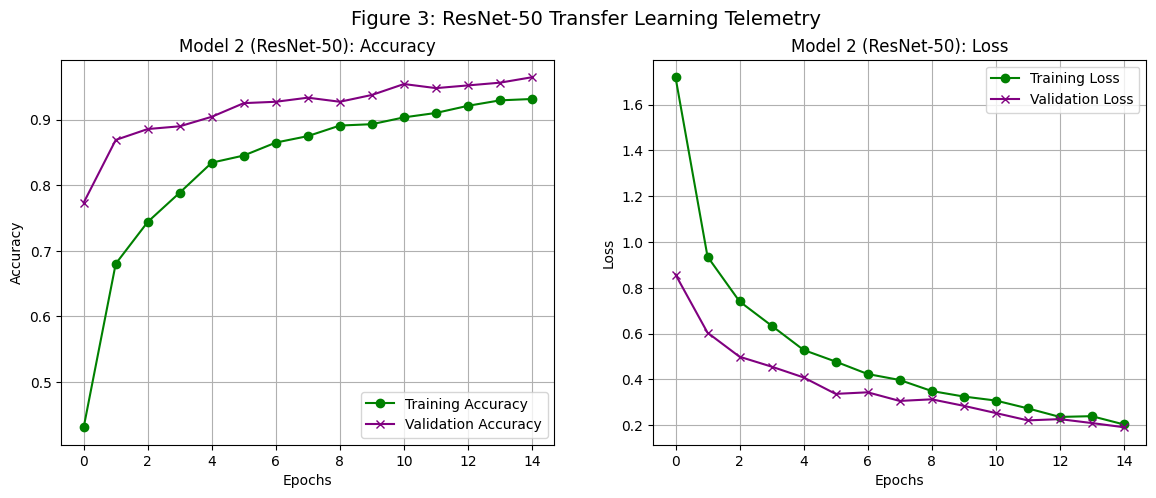

In [18]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("--- INITIATING SYSTEM RESET & RESNET-50 PIPELINE ---")

DATA_DIR = '/content/drive/MyDrive/Formula One Cars'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE

print("Loading telemetry data into memory...")
all_image_paths = []
all_image_labels = []
class_names = sorted([d.name for d in os.scandir(DATA_DIR) if d.is_dir()])
class_to_idx = {name: i for i, name in enumerate(class_names)}

for class_name in class_names:
    class_dir = os.path.join(DATA_DIR, class_name)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            all_image_paths.append(img_path)
            all_image_labels.append(class_to_idx[class_name])

all_image_paths_tf = tf.constant(all_image_paths, dtype=tf.string)
all_image_labels_tf = tf.constant(all_image_labels, dtype=tf.int32)

dataset = tf.data.Dataset.from_tensor_slices((all_image_paths_tf, all_image_labels_tf))
dataset = dataset.shuffle(buffer_size=len(all_image_paths), seed=123)

dataset_size = len(all_image_paths)
train_size = int(0.8 * dataset_size)
train_ds_raw = dataset.take(train_size)
val_ds_raw = dataset.skip(train_size)

def _decode_and_resize_img(img_path, label, img_size=(224, 224)):
    def _decode_image_py_func(path, lbl):
        try:
            img_bytes = tf.io.read_file(path)
            img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
            img = tf.image.resize(img, img_size)
            img = tf.cast(img, tf.uint8)
            return img, lbl, True
        except Exception as e:
            return tf.zeros((img_size[0], img_size[1], 3), dtype=tf.uint8), lbl, False

    image, label, success = tf.py_function(
        _decode_image_py_func, inp=[img_path, label], Tout=[tf.uint8, tf.int32, tf.bool]
    )
    image.set_shape([img_size[0], img_size[1], 3])
    label.set_shape([])
    success.set_shape([])
    return image, label, success

def configure_for_performance(ds, shuffle_data=False):
    ds = ds.map(lambda img_path, label: _decode_and_resize_img(img_path, label, IMG_SIZE), num_parallel_calls=AUTOTUNE)
    ds = ds.filter(lambda image, label, success: success)
    ds = ds.map(lambda image, label, success: (image, label))
    if shuffle_data:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.cache()
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_dataset = configure_for_performance(train_ds_raw, shuffle_data=True)
val_dataset = configure_for_performance(val_ds_raw)

print(f"Data Pipeline Re-established. Constructors locked: {len(class_names)}")

print("\nPulling ResNet-50 Architecture from the cloud...")
num_classes = len(class_names)

base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model2 = tf.keras.Model(inputs, outputs)
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

EPOCHS = 15
print("\nEngaging ResNet-50 Training Sequence...")
history2 = model2.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS)
print("\nResNet-50 Qualifying run complete. Generating Telemetry...")

acc2 = history2.history['accuracy']
val_acc2 = history2.history['val_accuracy']
loss2 = history2.history['loss']
val_loss2 = history2.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc2, label='Training Accuracy', color='green', marker='o')
plt.plot(epochs_range, val_acc2, label='Validation Accuracy', color='purple', marker='x')
plt.title('Model 2 (ResNet-50): Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss2, label='Training Loss', color='green', marker='o')
plt.plot(epochs_range, val_loss2, label='Validation Loss', color='purple', marker='x')
plt.title('Model 2 (ResNet-50): Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.suptitle("Figure 3: ResNet-50 Transfer Learning Telemetry", fontsize=14)
plt.show()
